# Tentative avec le SOM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio
from sklearn.manifold import MDS
import librosa
from scipy.cluster.hierarchy import linkage, dendrogram
import plotly.graph_objects as go
import os
import warnings
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
li_filenames = []

for racine, _, fichiers in os.walk('cross-era_chroma-nnls'):
    for fichier in fichiers:
        chemin_relatif = os.path.relpath(os.path.join(racine, fichier))
        li_filenames.append(chemin_relatif)

In [3]:
def dico_filenames(filename = "cross-era_annotations.csv"):
    dico = {}
    df = pd.read_csv(filename, sep=',')
    for i in range(len(df)):
        dico[df['Filename'][i]] = df['Composer'][i]
    return dico

In [4]:
dico_composers = dico_filenames()
a = np.array(list(dico_composers.values()))
np.unique(a)
# Imprime toutes les clés ayant pour valeur 'major'
for key, value in dico_composers.items():
    if value == ' major':
        print(key)
dico_composers["CrossEra-0616_Borodin_symphony_no.3_in_a_minor_moderato_assai.mp3"] = 'Borodin; Alexander'
dico_composers["CrossEra-0673_Liszt_poems__mazeppa.mp3"] = 'Liszt; Franz'
dico_composers["CrossEra-0674_Liszt_poems__prometheus.mp3"] = 'Liszt; Franz'
dico_composers["CrossEra-0776_Verdi_Overt_giovanna_darco_sinfonia.mp3"] = 'Verdi; Giuseppe'
dico_composers["CrossEra-1016_Cimarosa_Piano_sonata_no._24_in_b-flat_minor_major___andantino.mp3"] = 'Cimarosa; Domenico'

CrossEra-0616_Borodin_symphony_no.3_in_a_minor_moderato_assai.mp3
CrossEra-0673_Liszt_poems__mazeppa.mp3
CrossEra-0674_Liszt_poems__prometheus.mp3
CrossEra-0776_Verdi_Overt_giovanna_darco_sinfonia.mp3
CrossEra-1016_Cimarosa_Piano_sonata_no._24_in_b-flat_minor_major___andantino.mp3


In [5]:
# Load the data
with open("hist_cross-era.pkl", "rb") as f:
    dico_cross_era = pickle.load(f)

In [14]:
X = []
y = []
for file, histograms in dico_cross_era.items():
    composer = dico_composers[file.split('/')[1]]
    matrice = np.vstack(histograms)
    X.append(matrice.flatten())
    y.append(composer)
X = np.array(X)
y = np.array(y)

In [7]:
len(y)

1990

## Avec un entraînement stochastique

In [ ]:
from sklearn.cluster import KMeans

# === 4. Associer chaque entrée à un neurone et appliquer k-means à chaque neurone ===


In [ ]:
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from collections import defaultdict, Counter
import plotly.graph_objects as go

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# === 3. SOM training ===
som_size = 30
som = MiniSom(x=som_size, y=som_size, input_len=4896, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 2000)

# === 4. Associer chaque entrée à un neurone ===
winner_map = defaultdict(list)
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    winner_map[w].append(y[i])

# === 5. Préparation des données pour affichage Plotly ===
x_coords, y_coords, texts = [], [], []

for x in range(som_size):
    for y in range(som_size):
        x_coords.append(x)
        y_coords.append(y)
        comps = winner_map.get((x, y), [])
        if comps:
            counts = Counter(comps)
            text = "<br>".join([f"{k}: {v}" for k, v in counts.items()])
        else:
            text = "Aucun morceau"
        texts.append(text)

# === 6. Création de la figure Plotly ===
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_coords,
    y=y_coords,
    mode='markers',
    marker=dict(size=40, color='lightblue', line=dict(width=2, color='darkblue')),
    text=texts,
    hoverinfo='text'
))

fig.update_layout(
    title="Carte SOM interactive : Répartition des compositeurs par neurone",
    xaxis=dict(title="X", range=[-1, som_size], dtick=1),
    yaxis=dict(title="Y", range=[-1, som_size], dtick=1, autorange="reversed"),
    showlegend=False,
    width=60*som_size,
    height=60*som_size
)

fig.show()

## Tentative avec batch training

In [37]:
X = []
y = []
for file, histograms in dico_cross_era.items():
    composer = dico_composers[file.split('/')[1]]
    matrice = np.vstack(histograms)
    X.append(matrice.flatten())
    y.append(composer)
X = np.array(X)
y = np.array(y)

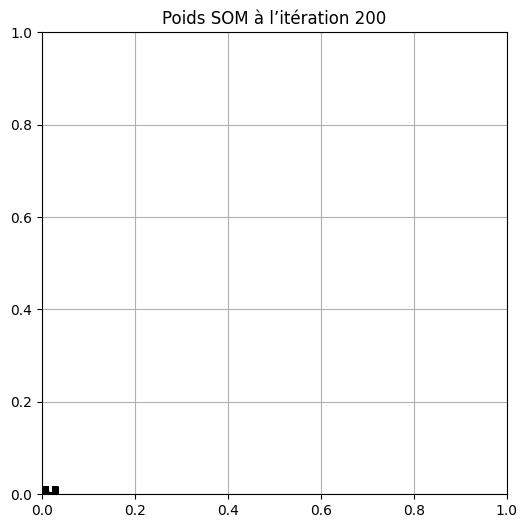

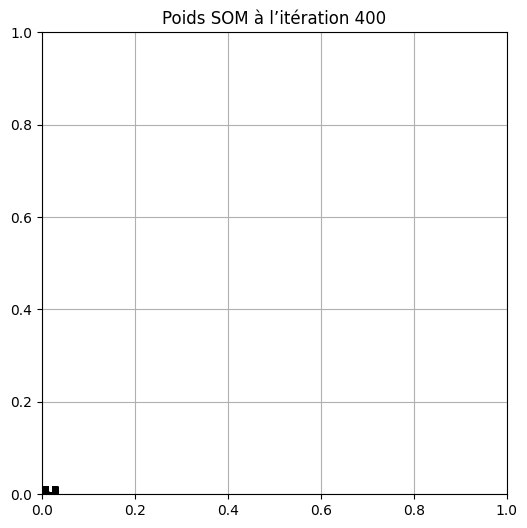

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

x_size, y_size = 7, 7
som = MiniSom(x=x_size, y=y_size, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)

n_total_iterations = 400
n_visualize_every = 200  # fréquence d’affichage

# === 4. Entraînement manuel étape par étape ===
def plot_weights(som, iteration):
    weights = som.get_weights()
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(x_size):
        for j in range(y_size):
            w = weights[i, j]
            ax.plot(w[0], w[1], 'o', markersize=6, color='blue')
            ax.text(w[0], w[1], f'{i},{j}', fontsize=8)
    ax.set_title(f'Poids SOM à l’itération {iteration}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.grid()
    plt.show()

for i in range(0, n_total_iterations, n_visualize_every):
    som.train_batch(X_scaled, n_visualize_every)
    plot_weights(som, i + n_visualize_every)

winner_map = defaultdict(list)
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    winner_map[w].append(y[i])

# === 5. Préparation des données pour affichage Plotly ===
x_coords, y_coords, texts = [], [], []

for x in range(som_size):
    for y in range(som_size):
        x_coords.append(x)
        y_coords.append(y)
        comps = winner_map.get((x, y), [])
        if comps:
            counts = Counter(comps)
            text = "<br>".join([f"{k}: {v}" for k, v in counts.items()])
        else:
            text = "Aucun morceau"
        texts.append(text)

# === 6. Création de la figure Plotly ===
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_coords,
    y=y_coords,
    mode='markers',
    marker=dict(size=40, color='lightblue', line=dict(width=2, color='darkblue')),
    text=texts,
    hoverinfo='text'
))

fig.update_layout(
    title="Carte SOM interactive : Répartition des compositeurs par neurone",
    xaxis=dict(title="X", range=[-1, som_size], dtick=1),
    yaxis=dict(title="Y", range=[-1, som_size], dtick=1, autorange="reversed"),
    showlegend=False,
    width=600,
    height=600
)

fig.show()



## Combinaison avec LDA

In [ ]:
import numpy as np
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import plotly.graph_objects as go
import plotly.express as px

# === 2. Normalisation ===
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#pca = PCA(n_components=1000)
#X_scaled = pca.fit_transform(X_scaled)

# === 3. SOM ===
som_size = 20
som = MiniSom(x=som_size, y=som_size, input_len=4896, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 2000)

# === 4. Cluster SOM ===
clusters = []
for x in X_scaled:
    w = som.winner(x)
    cluster_id = w[0] * som_size + w[1]
    clusters.append(cluster_id)
clusters = np.array(clusters)

# === 5. Encode compositeurs ===
le = LabelEncoder()
y_encoded = le.fit_transform(y)
compositeurs_unique = le.classes_

# === 6. LDA 3D ===
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X_scaled, y_encoded)

# === 7. Couleurs et symboles ===
num_clusters = som_size * som_size
colorscale = px.colors.qualitative.Plotly
symbols = ['circle', 'square', 'diamond', 'cross', 'x', 'circle-open', 'square-open', 'diamond-open']
# === 8. Création des traces groupées par cluster et compositeur ===
fig = go.Figure()

for cluster_id in np.unique(clusters):
    mask_cluster = (clusters == cluster_id)
    for comp_id in np.unique(y_encoded):
        mask_comp = (y_encoded == comp_id)
        mask = mask_cluster & mask_comp

        if np.sum(mask) == 0:
            continue
        
        fig.add_trace(go.Scatter3d(
            x=X_lda[mask, 0],
            y=X_lda[mask, 1],
            z=X_lda[mask, 2],
            mode='markers',
            marker=dict(
                size=6,
                color=colorscale[cluster_id % len(colorscale)],
                symbol=symbols[comp_id % len(symbols)],
                line=dict(width=0.5, color='black')
            ),
            name=f"{compositeurs_unique[comp_id]} (Cluster {cluster_id})",
            text=[f"Compositeur: {compositeurs_unique[comp_id]}<br>Cluster: {cluster_id}"] * np.sum(mask),
            hoverinfo='text'
        ))

fig.update_layout(
    title="Projection LDA 3D des morceaux avec clusters SOM",
    scene=dict(
        xaxis_title='LDA1',
        yaxis_title='LDA2',
        zaxis_title='LDA3',
    ),
    legend_title_text='Compositeurs (cluster)',
    width=900,
    height=700
)

fig.show()


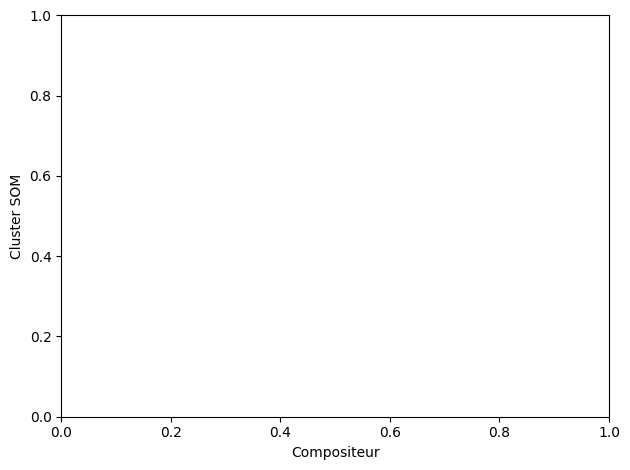

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute cluster for each sample
clusters = []
for sample in X:
    w = som.winner(scaler.transform([sample])[0])
    cluster_id = w[0] * som_size + w[1]
    clusters.append(cluster_id)
clusters = np.array(clusters)

# Build a DataFrame: rows=clusters, columns=composers, values=counts
df_heatmap = pd.DataFrame({'cluster': clusters, 'composer': y})
pivot = pd.pivot_table(df_heatmap, index='cluster', columns='composer', aggfunc=len, fill_value=0)

# Calculate percentages for annotation (for hover)
percentages = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0) * 100
hovertext = pivot.astype(str) + "<br>" + percentages.round(1).astype(str) + "%"

import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns,
    y=pivot.index,
    colorscale='YlGnBu',
    colorbar=dict(title="Nombre d'œuvres"),
    text=hovertext.values,
    hovertemplate="Cluster %{y}<br>Compositeur: %{x}<br>Nombre: %{z}<br>Pourcentage: %{text}<extra></extra>"
))

fig.update_layout(
    title="Répartition des compositeurs par cluster SOM<br>(Nombre d'œuvres, pourcentage au survol)",
    xaxis_title="Compositeur",
    yaxis_title="Cluster SOM",
    width=1800,
    height=900
)

fig.show()

## Combinaison avec K-means

In [21]:
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import random

# === 1. Simuler des données ===
np.random.seed(42)
n_samples = len(y)
n_features = 1000
n_clusters = 5

# Simuler des compositeurs et morceaux
compositeurs = y
morceaux = [f"Id {i}" for i in range(len(y))]

# === 2. Normaliser ===
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

if n_features != 4896:
    pca = PCA(n_components=n_features)
    X_scaled = pca.fit_transform(X_scaled)

# === 3. Entraîner le SOM ===
som_x, som_y = 40, 40
som = MiniSom(x=som_x, y=som_y, input_len=n_features, sigma=0.5, learning_rate=0.1)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 3000)

# === 4. Clustering K-Means sur les neurones ===
weights = som.get_weights().reshape(-1, n_features)
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
neuron_clusters = kmeans.fit_predict(weights)

# === 5. Associer données aux neurones ===
neuron_data = dict()  # {(x, y): [infos]}

for i in range(n_samples):
    bmu = som.winner(X_scaled[i])
    if bmu not in neuron_data:
        neuron_data[bmu] = []
    neuron_data[bmu].append((compositeurs[i], morceaux[i]))

# === 6. Préparer les données pour Plotly ===
cells_x, cells_y, texts, colors = [], [], [], []

for i in range(som_x):
    for j in range(som_y):
        idx = i * som_y + j
        cluster_id = neuron_clusters[idx]
        cells_x.append(i)
        cells_y.append(j)
        colors.append(cluster_id)

        # Info à afficher au survol
        if (i, j) in neuron_data:
            content = "<br>".join([f"{c} - {m}" for c, m in neuron_data[(i, j)]])
        else:
            content = "(aucun morceau)"
        texts.append(f"Cluster: {cluster_id}<br>{content}")

# === 7. Affichage interactif Plotly ===
fig = go.Figure(data=go.Scatter(
    x=cells_x,
    y=cells_y,
    mode='markers',
    marker=dict(
        size=40,
        color=colors,
        colorscale='Viridis',
        colorbar=dict(title="Cluster"),
        line=dict(width=2, color='gray'),
        symbol='square'
    ),
    text=texts,
    hoverinfo='text'
))

fig.update_layout(
    title="Carte SOM colorée par cluster (hover = compositeurs + morceaux)",
    xaxis=dict(title='SOM X', tickmode='linear', dtick=1),
    yaxis=dict(title='SOM Y', tickmode='linear', dtick=1),
    width=70*som_x,
    height=70*som_y,
    hoverlabel=dict(bgcolor="white", font_size=12),
)

fig.update_yaxes(autorange='reversed')  # Pour que (0,0) soit en haut à gauche
fig.show()